<a href="https://colab.research.google.com/github/joebathelt/AUC_Neuroimaging/blob/main/MindReading_Week11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nilearn

# When Decoding Doesn't Work: A Diagnostic Walkthrough

In last week's lab you ran a decoder on one participant from the Haxby dataset and it worked — the classifier could tell faces from cats from houses well above chance and showed perfect performance for faces vs houses. That's not a given. Most of the time in real research, the first time you run a decoder on a new dataset, the result lands somewhere between "disappointing" and "nothing." Today's lab is about what to do when that happens.

We'll take the **mixed gambles** dataset from Jimura & Poldrack (2012) and run a standard MVPA pipeline on it. The result will be near chance. Then we'll systematically diagnose *why*. This is the skill that separates "I ran an analysis" from "I understand what my analysis did."

## Learning objectives

By the end of this lab you should be able to:

1. Recognise the warning signs of a decoder that isn't learning (test accuracy at chance, high train accuracy).
2. Use three diagnostic probes — **train vs test comparison**, **permutation testing**, and **data inspection** — to identify specific failure modes.
3. Explain why a null MVPA result doesn't automatically mean "the brain doesn't represent this" — and why neither does a suspicious positive result automatically mean "it does."
4. Connect methodological choices (feature count, regularisation, preprocessing) to their consequences in cross-validated performance.

**What you'll do**:
- Run the standard decoding pipeline on one participant. See it fail.
- Apply three diagnostics to understand why.
- Confirm the pattern holds across the group.
- Pick one diagnostic of your own and run it.


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from nilearn import datasets, plotting, image
from nilearn.decoding import Decoder
from nilearn.maskers import NiftiMasker
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, permutation_test_score

%matplotlib inline
plt.rcParams['figure.dpi'] = 90


## Section 1 — Running the standard pipeline

### The dataset

Participants saw a series of mixed gambles in the scanner: a 50/50 chance to **gain** some amount of money or **lose** some amount. They decided whether to accept or reject each one. The published finding (Tom et al., 2007; Jimura & Poldrack, 2012) is that brain activity — particularly in the ventral striatum and ventromedial prefrontal cortex — tracks the magnitude of the potential gain.

The data are available via nilearn ([fetch_mixed_gambles](https://nilearn.github.io/stable/modules/generated/nilearn.datasets.fetch_mixed_gambles.html#nilearn.datasets.fetch_mixed_gambles)) and come to us already processed by a first-level GLM: one **z-map per trial** (48 trials per participant, 16 participants) with a gain **level** (1 = lowest, 8 = highest) as the trial label.

### Today's decoding question

We'll frame this as a binary classification: **low-value trials (levels 1–4) vs high-value trials (levels 5–8)**. If the brain represents value at all, a classifier should be able to distinguish these two classes. This is a standard MVPA setup and exactly the kind of question a paper might report.


In [ ]:
# Fetch the dataset (~100 MB; cached after first download)
data = datasets.fetch_mixed_gambles(n_subjects=16)

n_subjects = 16
gain_values = data.gain.to_numpy().ravel()
n_total_trials = len(gain_values)
n_trials_per_subject = n_total_trials // n_subjects

print(f"Total z-maps:                   {n_total_trials}")
print(f"Number of participants:          {n_subjects}")
print(f"Trials per participant:          {n_trials_per_subject}")


[fetch_mixed_gambles] Dataset found in /root/nilearn_data/jimura_poldrack_2012_zmaps

Total z-maps:                   768
Number of participants:          16
Trials per participant:          48


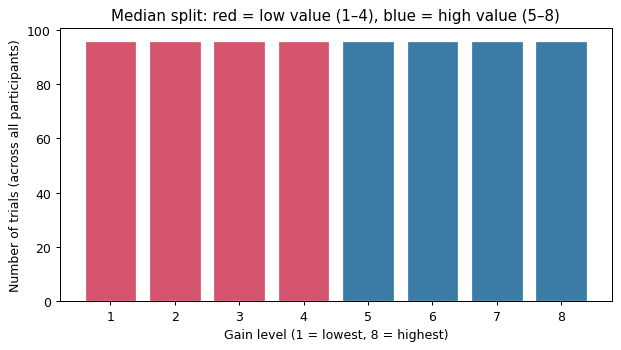

In [ ]:
# Visualise the distribution of gain levels, coloured by class
fig, ax = plt.subplots(figsize=(7, 4))
levels, counts = np.unique(gain_values, return_counts=True)
colors_bar = ['#d4546e' if lv <= 4 else '#3a7ca5' for lv in levels]
ax.bar(levels, counts, color=colors_bar, edgecolor='white')
ax.set_xlabel('Gain level (1 = lowest, 8 = highest)')
ax.set_ylabel('Number of trials (across all participants)')
ax.set_title('Median split: red = low value (1–4), blue = high value (5–8)')
plt.tight_layout()
plt.show()


### Helper: pull out one participant's data

Each participant's trials are stored consecutively in the dataset. This helper slices out one participant's z-maps and gain labels.


In [ ]:
def get_subject_data(data, subject_idx, n_trials_per_subject):
    """Return (z-maps, gain labels) for one participant."""
    start = subject_idx * n_trials_per_subject
    end = start + n_trials_per_subject

    if isinstance(data.zmaps, list):
        subject_zmaps = data.zmaps[start:end]
    else:
        subject_zmaps = image.index_img(data.zmaps, slice(start, end))

    subject_gain = data.gain.to_numpy().ravel()[start:end]
    return subject_zmaps, subject_gain


# Pull out participant 0 and apply the median split
sub0_zmaps, sub0_gain = get_subject_data(data, subject_idx=0, n_trials_per_subject=n_trials_per_subject)
sub0_binary = (sub0_gain >= 5).astype(int)

print(f"Participant 0: {len(sub0_gain)} trials")
print(f"Class balance: low={np.sum(sub0_binary == 0)}, high={np.sum(sub0_binary == 1)}")


Participant 0: 48 trials
Class balance: low=24, high=24


### Fit the decoder

This is the same workflow as last week — `nilearn`'s `Decoder`, linear SVC, whole-brain mask, 5-fold cross-validation, with feature screening to keep things tractable. We score with **ROC AUC**: 0.5 is chance, 1.0 is perfect.


In [ ]:
decoder = Decoder(
    estimator='svc',
    mask=data.mask_img,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    standardize=True,
    screening_percentile=10,
)

decoder.fit(sub0_zmaps, sub0_binary)

# Extract per-fold scores
fold_scores = list(decoder.cv_scores_.values())[-1]
mean_auc = float(np.mean(fold_scores))

print(f"Cross-validated AUC per fold: {[f'{s:.3f}' for s in fold_scores]}")
print(f"Mean AUC:                     {mean_auc:.3f}")
print(f"Chance level:                 0.5")


Cross-validated AUC per fold: ['0.143', '0.720', '0.280', '0.450', '0.857']
Mean AUC:                     0.490
Chance level:                 0.5


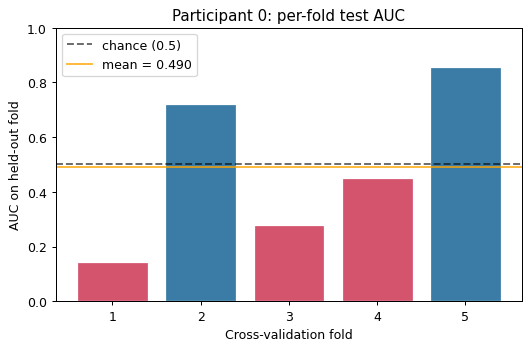

In [ ]:
# Visualise the per-fold AUC scores
fig, ax = plt.subplots(figsize=(6, 4))
bar_colors = ['#3a7ca5' if s >= 0.5 else '#d4546e' for s in fold_scores]
ax.bar(range(1, len(fold_scores) + 1), fold_scores, color=bar_colors, edgecolor='white')
ax.axhline(0.5, color='k', linestyle='--', alpha=0.6, label='chance (0.5)')
ax.axhline(mean_auc, color='orange', linestyle='-', alpha=0.8, label=f'mean = {mean_auc:.3f}')
ax.set_xlabel('Cross-validation fold')
ax.set_ylabel('AUC on held-out fold')
ax.set_title('Participant 0: per-fold test AUC')
ax.set_ylim(0, 1)
ax.set_xticks(range(1, len(fold_scores) + 1))
ax.legend()
plt.tight_layout()
plt.show()


### Something's off

Your mean AUC is hovering around 0.5 — chance level. This is a real and common situation, and the wrong reaction is to stop here and either report "no effect" or quietly try a different analysis until something works.

What we'll do instead is **diagnose** what happened. There are three possibilities worth ruling in or out:

1. The decoder is **overfitting** — it memorises the training data but fails to generalise.
2. Our **chance baseline** (0.5) is wrong in a subtle way, and the result is actually significant.
3. Something in the **data itself** is preventing the decoder from finding signal that's genuinely there.

Each of these calls for a different diagnostic.


## Section 2 — Three diagnostics

For these probes we'll step outside `nilearn`'s `Decoder` and use `scikit-learn` directly. The reason is practical: `Decoder` hides some details (training-set scoring, permutation testing) that we now need to see. First, we'll extract the voxel data into a standard `(n_trials, n_voxels)` array using `NiftiMasker`.


In [ ]:
# Mask all of participant 0's data to a 2D array
masker = NiftiMasker(mask_img=data.mask_img, standardize='zscore_sample')
X_sub0 = masker.fit_transform(sub0_zmaps)
y_sub0 = sub0_binary

print(f"Masked data shape: {X_sub0.shape}  (trials x voxels)")
print(f"Labels shape:      {y_sub0.shape}")


Masked data shape: (48, 33177)  (trials x voxels)
Labels shape:      (48,)


### Diagnostic 1 — Is the decoder overfitting?

A decoder that has memorised its training data but can't generalise will show a large gap between **training accuracy** (evaluated on the same data it was trained on) and **test accuracy** (evaluated on held-out data). This is the classic overfitting signature.

We'll run a 5-fold cross-validation loop manually, and for each fold compute AUC on both the training portion and the test portion.


In [ ]:
# Build a simple pipeline: feature selection + linear SVC
# Using SelectKBest with k=500 voxels — tighter than 'percentile=10' so this runs fast
pipe = Pipeline([
    ('select', SelectKBest(f_classif, k=500)),
    ('clf', SVC(kernel='linear', probability=True)),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

train_scores = []
test_scores = []

for train_idx, test_idx in cv.split(X_sub0, y_sub0):
    pipe.fit(X_sub0[train_idx], y_sub0[train_idx])
    # Score on both the training set and the held-out test set
    train_auc = pipe.score(X_sub0[train_idx], y_sub0[train_idx])
    test_auc = pipe.score(X_sub0[test_idx], y_sub0[test_idx])
    train_scores.append(train_auc)
    test_scores.append(test_auc)

train_scores = np.array(train_scores)
test_scores = np.array(test_scores)

print(f"Train accuracy per fold: {[f'{s:.3f}' for s in train_scores]}")
print(f"Test  accuracy per fold: {[f'{s:.3f}' for s in test_scores]}")
print()
print(f"Mean train accuracy: {train_scores.mean():.3f}")
print(f"Mean test accuracy:  {test_scores.mean():.3f}")
print(f"Gap:                 {train_scores.mean() - test_scores.mean():.3f}")


Train accuracy per fold: ['1.000', '1.000', '1.000', '1.000', '1.000']
Test  accuracy per fold: ['0.200', '0.800', '0.400', '0.333', '0.667']

Mean train accuracy: 1.000
Mean test accuracy:  0.480
Gap:                 0.520


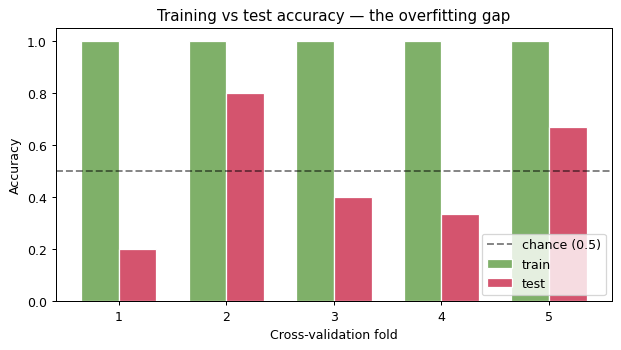

In [ ]:
# Plot the gap visually
fig, ax = plt.subplots(figsize=(7, 4))
folds = np.arange(1, len(train_scores) + 1)
width = 0.35
ax.bar(folds - width/2, train_scores, width, label='train', color='#7fb069', edgecolor='white')
ax.bar(folds + width/2, test_scores, width, label='test',  color='#d4546e', edgecolor='white')
ax.axhline(0.5, color='k', linestyle='--', alpha=0.5, label='chance (0.5)')
ax.set_xlabel('Cross-validation fold')
ax.set_ylabel('Accuracy')
ax.set_title('Training vs test accuracy — the overfitting gap')
ax.set_ylim(0, 1.05)
ax.set_xticks(folds)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


> **Reflect on Diagnostic 1**:
> 1. The training accuracy is near-perfect. The test accuracy is at chance. What does this tell you? (Hint: with 500 voxels and ~38 training trials)
> 2. Is high training accuracy good news? Why or why not?
> 3. If overfitting is the problem, what kinds of fixes would you consider?


### Diagnostic 2 — Is 0.5 really our chance baseline?

Our AUC of ~0.5 *looks* like chance, but "chance" in a small, high-dimensional dataset is not as well-defined as textbooks suggest. A proper answer requires building an empirical null distribution: shuffle the labels, run the same pipeline, record the AUC. Do this many times, and you have the distribution of AUCs you'd get *if there were no relationship at all* between voxels and labels.

We run 50 permutations — enough to see the shape of the null distribution without eating all of class time. If you have time, try running 500 or 1000 permutations to get a more precise p-value.


In [ ]:
# This takes ~30–60 seconds on Colab
score, perm_scores, p_value = permutation_test_score(
    pipe,
    X_sub0, y_sub0,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_permutations=50,
    random_state=42,
    n_jobs=-1,
)

print(f"Observed (real-label) accuracy:       {score:.3f}")
print(f"Null distribution (shuffled labels):")
print(f"  mean = {perm_scores.mean():.3f}")
print(f"  5th–95th percentile = {np.percentile(perm_scores, 5):.3f} – {np.percentile(perm_scores, 95):.3f}")
print(f"Permutation p-value: {p_value:.3f}")


Observed (real-label) accuracy:       0.480
Null distribution (shuffled labels):
  mean = 0.489
  5th–95th percentile = 0.352 – 0.662
Permutation p-value: 0.588


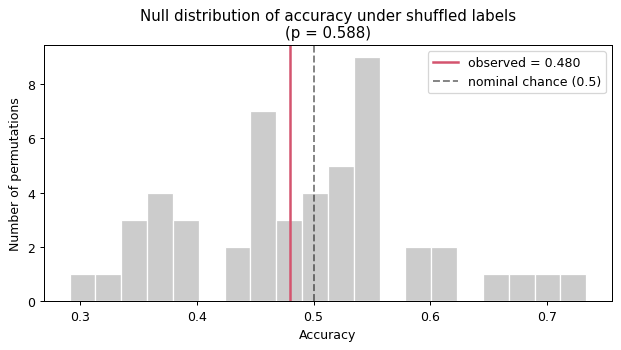

In [ ]:
# Plot the null distribution with the observed score marked
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_scores, bins=20, color='#cccccc', edgecolor='white')
ax.axvline(score, color='#d4546e', linestyle='-', linewidth=2,
           label=f'observed = {score:.3f}')
ax.axvline(0.5, color='k', linestyle='--', alpha=0.5, label='nominal chance (0.5)')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Number of permutations')
ax.set_title(f'Null distribution of accuracy under shuffled labels\n(p = {p_value:.3f})')
ax.legend()
plt.tight_layout()
plt.show()


> **Reflect on Diagnostic 2**:
> 1. Where does the observed accuracy sit in the null distribution? Is it in the tails, or right in the middle?
> 2. Is the null distribution centred on 0.5, or somewhere else? If it's shifted, what might cause that? (Hint: think about class balance and small-sample bias.)
> 3. What does the permutation p-value let you conclude that a simple "is AUC > 0.5?" test doesn't?


### Diagnostic 3 — What's actually in the data?

So far our decoder-focused probes suggest overfitting and a result indistinguishable from chance. But maybe the problem is upstream. Sometimes data has been processed in ways that remove the signal the decoder is looking for.

Let's take one participant's z-maps and, for each voxel, compute the **mean across trials**. If the dataset has been standardised per-voxel across trials (a common preprocessing step, but not always appropriate), these means will all be exactly zero — a telltale sign.


In [ ]:
# Re-load without any masker-level standardisation so we see the raw data
masker_raw = NiftiMasker(mask_img=data.mask_img, standardize=False)
X_raw = masker_raw.fit_transform(sub0_zmaps)

# For each voxel, compute the mean across the 48 trials
voxel_means = X_raw.mean(axis=0)
voxel_stds = X_raw.std(axis=0)

print(f"Across {X_raw.shape[1]} voxels:")
print(f"  Mean of per-voxel trial means: {voxel_means.mean():+.4f}")
print(f"  SD   of per-voxel trial means: {voxel_means.std():.4f}")
print(f"  Mean of per-voxel trial SDs:   {voxel_stds.mean():.4f}")


Across 33177 voxels:
  Mean of per-voxel trial means: -0.0000
  SD   of per-voxel trial means: 0.0000
  Mean of per-voxel trial SDs:   0.9838


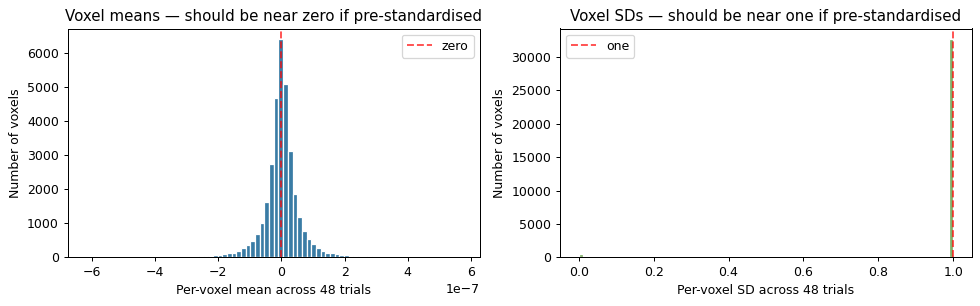

In [ ]:
# Plot the histograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))

ax1.hist(voxel_means, bins=80, color='#3a7ca5', edgecolor='white')
ax1.axvline(0, color='r', linestyle='--', alpha=0.7, label='zero')
ax1.set_xlabel('Per-voxel mean across 48 trials')
ax1.set_ylabel('Number of voxels')
ax1.set_title('Voxel means — should be near zero if pre-standardised')
ax1.legend()

ax2.hist(voxel_stds, bins=80, color='#7fb069', edgecolor='white')
ax2.axvline(1, color='r', linestyle='--', alpha=0.7, label='one')
ax2.set_xlabel('Per-voxel SD across 48 trials')
ax2.set_ylabel('Number of voxels')
ax2.set_title('Voxel SDs — should be near one if pre-standardised')
ax2.legend()

plt.tight_layout()
plt.show()


> **Reflect on Diagnostic 3**:
> 1. The per-voxel means are essentially all zero, and the SDs are essentially all one. What does this tell you about how the data was preprocessed before we got it?
> 2. Why might this specific preprocessing choice hurt a classifier that tries to distinguish high- from low-value trials? (Hint: if the mean signal across trials is forced to zero, what kind of information has been removed?)
> 3. Look up `_load_mixed_gambles` in the [nilearn source](https://github.com/nilearn/nilearn/blob/main/nilearn/datasets/func.py). The standardisation is done deliberately — the nilearn gallery example on this dataset uses an ensemble method (FREM) that benefits from it. Why might a choice that *helps* one method *hurt* another?


## Section 3 — Does this fail for everyone?

One participant might just be noisy. Before concluding the dataset is genuinely hostile to standard decoding, we should check whether the pattern holds across all 16 participants. We'll run the basic `nilearn` `Decoder` (not the full diagnostic battery) for each one, then test the distribution of AUCs against 0.5 with a one-sample t-test.


In [ ]:
subject_scores = []

for sub_idx in range(n_subjects):
    s_zmaps, s_gain = get_subject_data(data, sub_idx, n_trials_per_subject)
    s_binary = (s_gain >= 5).astype(int)

    s_decoder = Decoder(
        estimator='svc',
        mask=data.mask_img,
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        scoring='roc_auc',
        standardize=True,
        screening_percentile=10,
    )
    s_decoder.fit(s_zmaps, s_binary)

    fold_scores = list(s_decoder.cv_scores_.values())[-1]
    mean_auc = float(np.mean(fold_scores))
    subject_scores.append(mean_auc)

    print(f"Participant {sub_idx:2d}: AUC = {mean_auc:.3f}")

subject_scores = np.array(subject_scores)


Participant  0: AUC = 0.490
Participant  1: AUC = 0.562
Participant  2: AUC = 0.219
Participant  3: AUC = 0.543
Participant  4: AUC = 0.485
Participant  5: AUC = 0.505
Participant  6: AUC = 0.402
Participant  7: AUC = 0.461
Participant  8: AUC = 0.436
Participant  9: AUC = 0.414
Participant 10: AUC = 0.474
Participant 11: AUC = 0.335
Participant 12: AUC = 0.667
Participant 13: AUC = 0.568
Participant 14: AUC = 0.451
Participant 15: AUC = 0.512


In [ ]:
# Group-level test
t_stat, p_val = stats.ttest_1samp(subject_scores, popmean=0.5)

print(f"Group mean AUC ± SD: {subject_scores.mean():.3f} ± {subject_scores.std():.3f}")
print(f"One-sample t-test against 0.5: t({n_subjects - 1}) = {t_stat:.2f}, p = {p_val:.4f}")


Group mean AUC ± SD: 0.470 ± 0.099
One-sample t-test against 0.5: t(15) = -1.17, p = 0.2618


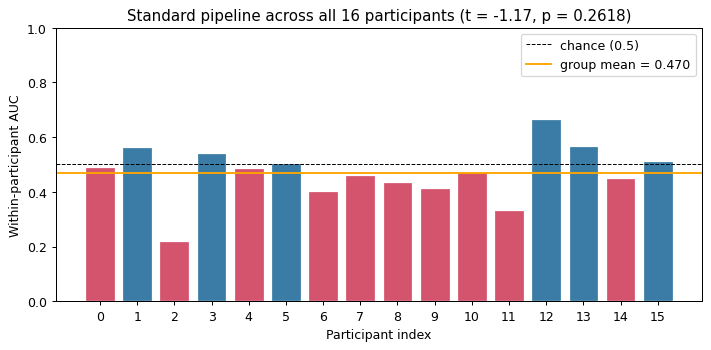

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#3a7ca5' if s > 0.5 else '#d4546e' for s in subject_scores]
ax.bar(range(n_subjects), subject_scores, color=colors, edgecolor='white')
ax.axhline(0.5, color='k', linewidth=0.8, linestyle='--', label='chance (0.5)')
ax.axhline(subject_scores.mean(), color='orange', linestyle='-',
           label=f'group mean = {subject_scores.mean():.3f}')
ax.set_xlabel('Participant index')
ax.set_ylabel('Within-participant AUC')
ax.set_title(f'Standard pipeline across all 16 participants '
             f'(t = {t_stat:.2f}, p = {p_val:.4f})')
ax.set_xticks(range(n_subjects))
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


### What Jimura & Poldrack actually did

The original [Jimura & Poldrack (2012)](https://www.sciencedirect.com/science/article/pii/S0028393211005070) paper reports that value information *is* decodable from these brains. So why is our standard pipeline finding nothing?

Two reasons, now visible in light of the diagnostics:

1. They used **across-participant decoding with ensemble methods** (the [FREM](https://nilearn.github.io/stable/decoding/frem.html) approach later built into nilearn), which aggregates thousands of regularised models and is designed to extract robust signal from data exactly like this. The per-voxel standardisation that hurt our simple SVC is specifically useful for FREM's ensembling logic.
2. They had access to **trial-level information** we don't (which specific gain amount in dollars, the loss amount, the participant's actual choice) — we only have the ordinal gain levels.

The lesson isn't "our pipeline is broken." It's that **method and data have to match**. A standard within-participant SVC is a perfectly good decoder for data with many trials per participant and no heavy preprocessing; it's the wrong tool for data with few trials per participant that's been pre-standardised for a different purpose. Recognising this mismatch *is the analysis*.

## Section 4 — Your turn

Pick exactly one of the three options below. Each maps onto a diagnostic we ran in Section 2. The pedagogical point is not to fix the decoder — we've just seen why that's hard — but to **run one more diagnostic of your own** and interpret what it tells you.

For your chosen option:

1. Read the description and write down (in a comment) what you predict will happen and why.
2. Implement the change.
3. Run it on **participant 0**.
4. Write a one-sentence interpretation.

---

**Option A — Tighter regularisation (connects to Diagnostic 1).**
Change `SelectKBest(k=500)` to `SelectKBest(k=20)`. Predict: what should happen to the train-test gap? Does the test accuracy come up off the floor?

```python
# pipe_small = Pipeline([('select', SelectKBest(f_classif, k=20)),
#                        ('clf', SVC(kernel='linear'))])
# Then re-run the manual CV loop from Diagnostic 1.
```

---

**Option B — Permutation test with a restricted ROI (connects to Diagnostic 2).**
Re-run the permutation test using only voxels in a specific ROI (e.g. the Harvard-Oxford frontal medial cortex, where value signals are expected). Predict: does the observed score move in the null distribution? Does restricting to a plausible region change what "chance" looks like?

```python
# from nilearn.datasets import fetch_atlas_harvard_oxford
# atlas = fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
# Then make an ROI-specific masker and redo the permutation test.
```

---

**Option C — Re-inspect the data after *un*-standardising (connects to Diagnostic 3).**
The per-voxel standardisation is a deliberate preprocessing choice. You can't fully undo it (the raw means are lost), but you can see what the decoder makes of the data if you *add* a per-class mean shift — essentially simulating what the data might look like if value information were encoded in overall activation level. Pick a small cluster of voxels, add a constant to the high-value trials there, and re-run the decoder. Predict: how much added signal is needed before the decoder starts succeeding?

```python
# shift = 0.5  # try different values
# X_shifted = X_sub0.copy()
# target_voxels = slice(0, 100)  # first 100 voxels, arbitrary
# X_shifted[y_sub0 == 1, target_voxels] += shift
# Then re-run the manual CV loop.
```

---


In [ ]:
# ===== YOUR EXERCISE STARTS HERE =====
# Step 1 — Write your PREDICTION as a comment before writing any code.

# MY PREDICTION:
#

# Step 2 — Implement your chosen diagnostic.


# Step 3 — Run it on participant 0 and report the result.


# Step 4 — Write a one-sentence interpretation.

# MY INTERPRETATION:
#


## Wrap-up

This was quite different from the clean example we analysed last week. Rather than a clean decoding result with a satisfying weight map, you spent the session investigating why a reasonable pipeline produced an unreasonable-looking answer. The three takeaways worth keeping:

- **A null result is not nothing.** It's a claim, specifically, a claim that *this method, on this data, doesn't extract this pattern*. The cause can be the method, the data, or both, and the diagnostics you ran today are how you tell them apart. Without that work, you don't have a result, but only uncertainty.
- **Overfitting is not a glitch to be hidden; it's information.** The huge gap between training and test accuracy in Section 2 was arguably more informative than the test accuracy by itself. When you see it, you know where to look for fixes.
- **Preprocessing choices are analytical choices.** The per-voxel standardisation baked into the data loader was the right choice for the method the original authors used. It was the wrong choice for ours. Methodological fit is upstream of almost every result.

Hopefully, following these steps in an actual analysis underlines one of the key takeaway message from this course. Analyses consist of methodological choices that determine the results that we can obtain. Understanding the consequences of those choices is how we understand and interpret our results.

### References

Jimura, K., & Poldrack, R. A. (2012). Analyses of regional-average activation and multivoxel pattern information tell complementary stories. *Neuropsychologia*, 50(4), 544–552. [link](https://www.sciencedirect.com/science/article/pii/S0028393211005070)

Tom, S. M., Fox, C. R., Trepel, C., & Poldrack, R. A. (2007). The neural basis of loss aversion in decision-making under risk. *Science*, 315(5811), 515–518.
